In [15]:
# ======= Import des librairies =======

import os # gérer les dossiers et fichiers
import zipfile # décompresser des fichiers .zip
import numpy as np # manipuler les matrices, convertir les images en tableaux
import matplotlib.pyplot as plt # visualiser images, courbes et matrices
import seaborn as sns # visualiser images, courbes et matrices
import tensorflow as tf # créer et entraîner le CNN
from tensorflow import keras # créer et entraîner le CNN
from tensorflow.keras import layers, models # pour construire les couches et le modèle séquentiel
from tensorflow.keras.preprocessing.image import ImageDataGenerator # pour charger les images et faire du data augmentation
from tensorflow.keras.preprocessing import image # charger et préparer une image individuelle pour prédiction
from sklearn.metrics import classification_report, confusion_matrix # évaluer la performance du modèle
import random # choisir aléatoirement des images pour visualisation

In [16]:
# ======= CONNEXION AU DRIVE ET EXTRACTION DU DATASET =======

from google.colab import drive

# Nom du dossier partagé dans Google Drive
nom_dossier_drive = 'Projet_CNN'
nom_fichier_zip = 'Dataset.zip'

# Dossier d'extraction local (rapide)
dossier_extraction = '/content/dataset'

print("🔗 Connexion à Google Drive...")
drive.mount('/content/drive')

chemin_zip = f'/content/drive/MyDrive/{nom_dossier_drive}/{nom_fichier_zip}'

# Vérification et extraction
if os.path.exists(chemin_zip):
    print("Dataset trouvé dans Drive")

    if not os.path.exists(dossier_extraction):
        print("Extraction du dataset...")
        with zipfile.ZipFile(chemin_zip, 'r') as zip_ref:
            zip_ref.extractall(dossier_extraction)
        print("Extraction terminée")
    else:
        print("Dataset déjà extrait!!")
else:
    print("Fichier introuvable dans Drive")


🔗 Connexion à Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset trouvé dans Drive
Dataset déjà extrait!!


In [17]:
# ======= DÉTECTION DES DOSSIERS TRAIN / TEST =======

train_dir, test_dir = None, None

for root, dirs, files in os.walk(dossier_extraction):
    for d in dirs:
        if d.lower() in ['train', 'training']:
            train_dir = os.path.join(root, d)
        elif d.lower() in ['test', 'testing', 'validation']:
            test_dir = os.path.join(root, d)

print("Train :", train_dir)
print("Test  :", test_dir)


Train : /content/dataset/Dataset/Training
Test  : /content/dataset/Dataset/Testing


In [18]:
# --- Paramètres ---

IMG_WIDTH, IMG_HEIGHT = 150, 150 # Les images sont redimensionnées à 150×150 pixels
BATCH_SIZE = 32                  # On envoie 32 images à la fois au modèle
EPOCHS = 15                      # Nombre de fois que le modèle verra tout le dataset

In [19]:
# --- Générateur pour l'entraînement (AVEC Data Augmentation) ---
# DATA AUGMENTATION Permet :
# - d'augmenter artificiellement le dataset
# - de réduire l'overfitting
# - d'améliorer la généralisation du CNN

train_datagen = ImageDataGenerator( # normalise les pixels et fait des transformations aléatoires pour enrichir le dataset
    rescale=1./255,         # Normalisation : convertit les pixels (0–255) en 0–1
    rotation_range=20,      # Rotation aléatoire
    width_shift_range=0.1,  # Décalage largeur
    height_shift_range=0.1, # Décalage hauteur
    shear_range=0.1,        # Cisaillement
    zoom_range=0.1,         # Zoom
    horizontal_flip=True,   # Miroir horizontal
    fill_mode='nearest',    # Gestion des pixels vides créés par la rotation
    validation_split=0.2    # On réserve 20% des images d’entraînement pour la validation
)

# --- Générateur pour le test (SANS Data Augmentation) ---

# On ne modifie jamais les images de test, on les normalise juste.
test_datagen = ImageDataGenerator(rescale=1./255)

print("Générateurs configurés.")

Générateurs configurés.


In [20]:
# --- 1. Chargement des images d'entraînement (80%) ---

print("--- Chargement Entraînement ---")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',    # Classification binaire (tumeur / sain)
    subset='training',
    shuffle=True
)

# --- 2. Chargement des images de validation (20%) ---
print("\n--- Chargement Validation ---")
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=True
)

# --- 3. Chargement des images de test (Dossier Testing) ---
if os.path.exists(test_dir):
    print("\n--- Chargement Test ---")
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(IMG_WIDTH, IMG_HEIGHT),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False # IMPORTANT : False pour garder l'ordre pour la matrice de confusion
    )
else:
    print(f"\n Attention : Le dossier {test_dir} n'existe pas.")

# Petit check pour voir les indices
print("\nIndices des classes :", train_generator.class_indices)

--- Chargement Entraînement ---
Found 6622 images belonging to 2 classes.

--- Chargement Validation ---
Found 1655 images belonging to 2 classes.

--- Chargement Test ---
Found 1816 images belonging to 2 classes.

Indices des classes : {'no tumor': 0, 'tumor': 1}


Exemples d'images générées (avec déformations aléatoires) :


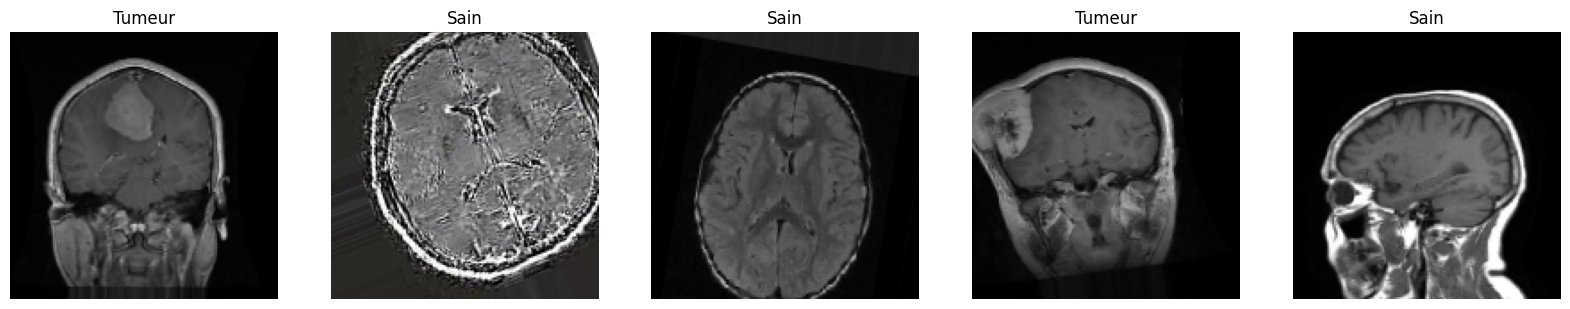

In [30]:
# 1. On demande au générateur un lot d'images (batch)
images_augmentees, labels = next(train_generator)

# 2. Créer une figure pour afficher les 5 premières images du lot
plt.figure(figsize=(20, 10))

print("Exemples d'images générées (avec déformations aléatoires) :")

for i in range(5):
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(images_augmentees[i])

    # On affiche le label (0 ou 1)
    status = "Tumeur" if labels[i] == 1 else "Sain"
    plt.title(status)
    plt.axis("off")

plt.show()

In [31]:
# --- Création du modèle CNN ---
model = models.Sequential([

    # ===== 1er bloc convolutif =====
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)),
    # 32 filtres (kernels de taille 3*3)
    # pour que chaque filtre va apprendre une caractéristique différente (bord, texture…)
    layers.MaxPooling2D(2,2),
    # Réduit la taille de la feature map de moitié

    # ===== 2ème bloc convolutif =====
    layers.Conv2D(64, (3,3), activation='relu'),
    # 64 filtres, plus de filtres pour capturer des caractéristiques plus complexes (formes, motifs spécifiques aux tumeurs)
    layers.MaxPooling2D(2,2),

    # ===== 3ème bloc convolutif =====
    layers.Conv2D(128, (3,3), activation='relu'),
    # 128 filtres, pour capturer des caractéristiques encore plus fines et abstraites
    layers.MaxPooling2D(2,2),

    # ===== Flatten + Fully Connected =====
    layers.Flatten(), # transforme la matrice 3D en vecteur 1D pour pouvoir le passer à des couches fully connected.
    layers.Dense(128, activation='relu'), # Combine toutes les caractéristiques en 128 neurones pour la décision

    # ===== Dropout =====
    # (Désactive 50% des neurones aléatoirement pour éviter l’overfitting)
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')  # Sortie binaire (0 ou 1)
    # 1 neurone, car on fait une classification binaire (0 = sain, 1 = tumeur)
    # activation='sigmoid' : renvoie une valeur entre 0 et 1 → probabilité que l’image soit une tumeur
])

# Compiler le modèle
model.compile(optimizer='adam', # C'est un algorithme qui met à jour les poids du réseau pour minimiser la fonction de perte

              loss='binary_crossentropy', # Fonction de perte binaire qui mesure la différence entre la sortie prédite et la vraie classe
              metrics=['accuracy']) # demander au modèle de suivre la précision (accuracy) pendant l’entraînement

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# ======= Entraîne le CNN sur les images d’entraînement =======

print("Début de l'entraînement...")
history = model.fit(
    train_generator,                     # Images pour apprendre
    epochs=EPOCHS,                       # 15 tours complets
    validation_data=validation_generator # Images pour vérifier sans apprendre
)
print("Entraînement terminé !")

Début de l'entraînement...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
207/207 ━━━━━━━━━━━━━━━━━━━━ 64s 291ms/step - accuracy: 0.7823 - loss: 0.4645 - val_accuracy: 0.8417 - val_loss: 0.4011
Epoch 2/15
207/207 ━━━━━━━━━━━━━━━━━━━━ 55s 266ms/step - accuracy: 0.9446 - loss: 0.1792 - val_accuracy: 0.8580 - val_loss: 0.3886
Epoch 3/15
207/207 ━━━━━━━━━━━━━━━━━━━━ 53s 255ms/step - accuracy: 0.9511 - loss: 0.1489 - val_accuracy: 0.9142 - val_loss: 0.2210
Epoch 4/15
207/207 ━━━━━━━━━━━━━━━━━━━━ 53s 255ms/step - accuracy: 0.9573 - loss: 0.1244 - val_accuracy: 0.9063 - val_loss: 0.2568
Epoch 5/15
207/207 ━━━━━━━━━━━━━━━━━━━━ 54s 259ms/step - accuracy: 0.9676 - loss: 0.1024 - val_accuracy: 0.9776 - val_loss: 0.0786
Epoch 6/15
207/207 ━━━━━━━━━━━━━━━━━━━━ 53s 255ms/step - accuracy: 0.9652 - loss: 0.1078 - val_accuracy: 0.9498 - val_loss: 0.1324
Epoch 7/15
207/207 ━━━━━━━━━━━━━━━━━━━━ 53s 255ms/step - accuracy: 0.9673 - loss: 0.0933 - val_accuracy: 0.9486 - val_loss: 0.1395
Epoch 8/15
207/207 ━━━━━━━━━━━━━━━━━━━━ 53s 256ms/step - accuracy: 0.9727 - loss: 0

In [33]:
print("--- ÉVALUATION FINALE ---")

# Teste le modèle sur validation et retourne : erreur et précision
if 'test_generator' in locals():
    test_loss, test_acc = model.evaluate(test_generator) # Évalue le modèle sur les images de test jamais vues
    print(f"\n🎯 Précision Finale (Accuracy) : {test_acc*100:.2f}%") # et Affiche la précision et la perte finale
    print(f"📉 Perte Finale (Loss) : {test_loss:.4f}")
else:
    print("Erreur : Le test_generator n'est pas chargé.")

--- ÉVALUATION FINALE ---
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - accuracy: 0.9777 - loss: 0.0604

🎯 Précision Finale (Accuracy) : 95.04%
📉 Perte Finale (Loss) : 0.1054


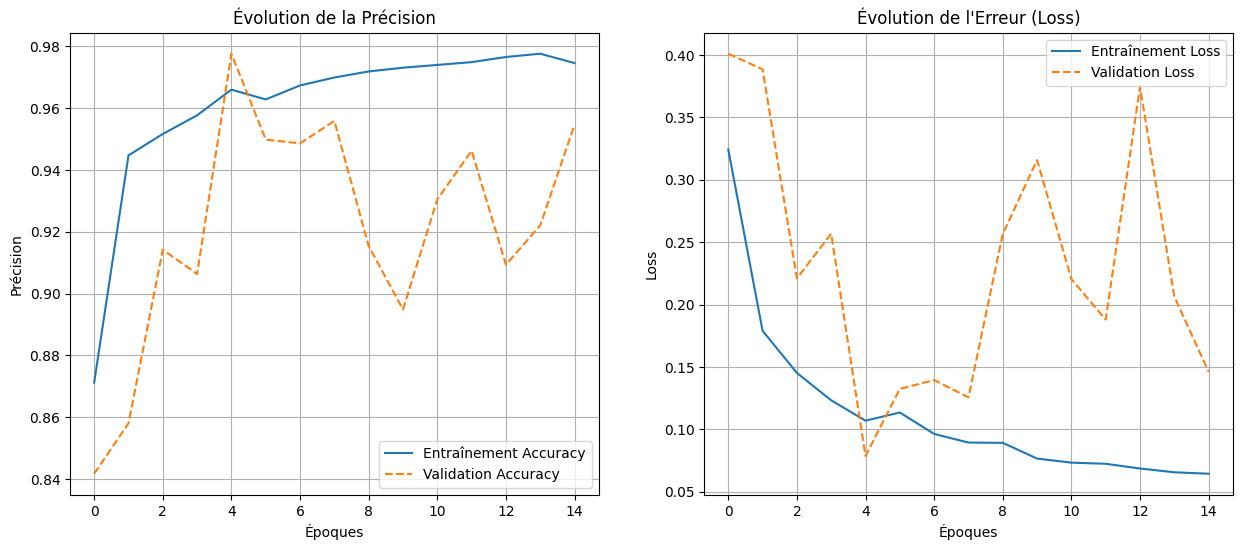

In [35]:
# Récupération des données de l'historique

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# On définit l'axe des X
epochs_range = range(len(acc))

plt.figure(figsize=(15, 6))

# --- GRAPHIQUE 1 : PRÉCISION (Accuracy) ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Entraînement Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linestyle='--')
plt.legend(loc='lower right')
plt.title('Évolution de la Précision')
plt.xlabel('Époques')
plt.ylabel('Précision')
plt.grid(True)

# --- GRAPHIQUE 2 : PERTE (Loss) ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Entraînement Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss', linestyle='--')
plt.legend(loc='upper right')
plt.title('Évolution de l\'Erreur (Loss)')
plt.xlabel('Époques')
plt.ylabel('Loss')
plt.grid(True)

plt.show()

Calcul des prédictions en cours...
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step


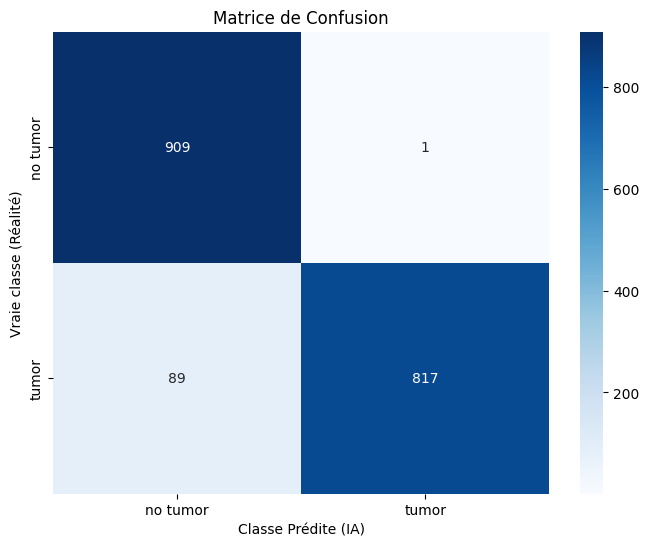


--- RAPPORT DÉTAILLÉ ---
              precision    recall  f1-score   support

    no tumor       0.91      1.00      0.95       910
       tumor       1.00      0.90      0.95       906

    accuracy                           0.95      1816
   macro avg       0.95      0.95      0.95      1816
weighted avg       0.95      0.95      0.95      1816



In [36]:
# 1. Faire les prédictions sur tout le dossier de test
print("Calcul des prédictions en cours...")
predictions = model.predict(test_generator) # fait les prédictions
predicted_classes = (predictions > 0.5).astype("int32") # Convertit les probabilités en 0 ou 1

# 2. Récupérer les vraies réponses
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# 3. Créer la matrice
cm = confusion_matrix(true_classes, predicted_classes)


# 4. Affichage visuel
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Matrice de Confusion')
plt.ylabel('Vraie classe (Réalité)')
plt.xlabel('Classe Prédite (IA)')
plt.show()

# 5. Rapport détaillé
print("\n--- RAPPORT DÉTAILLÉ ---")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

Génération des prédictions pour 5 images aléatoires...


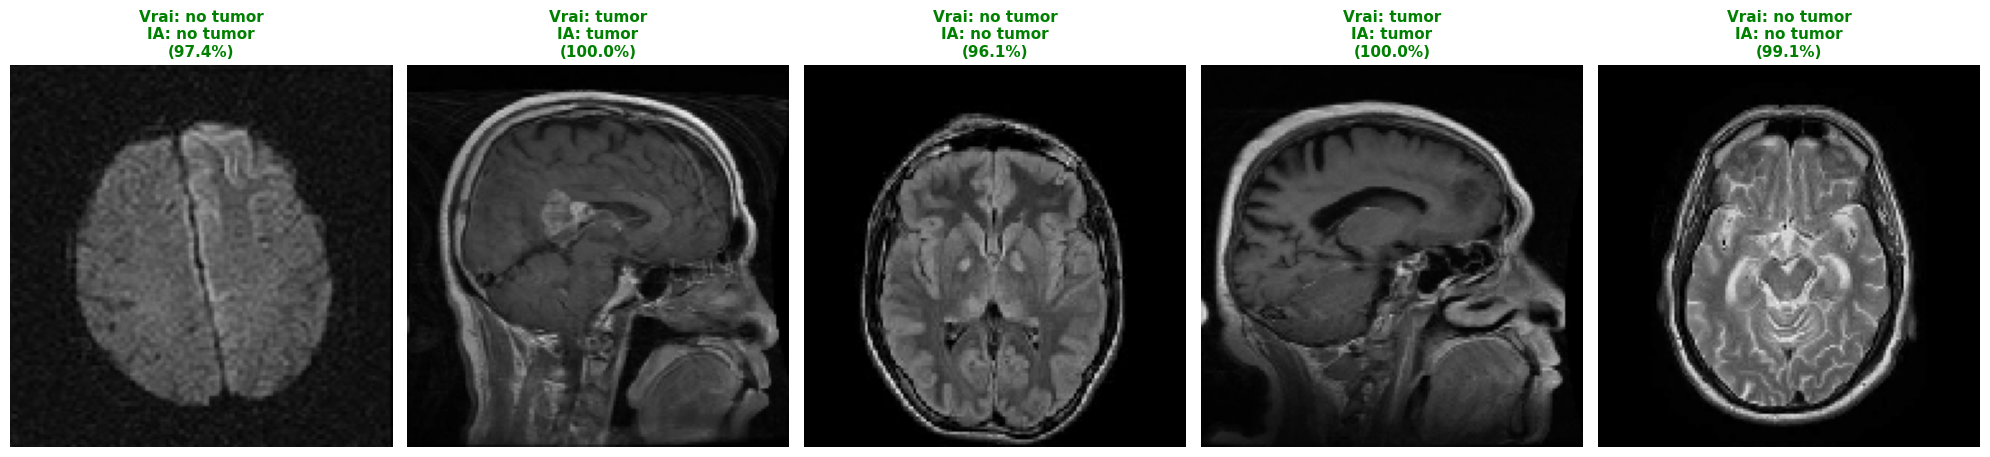

In [52]:
# --- Configuration ---
# On utilise la variable test_dir définie au début pour éviter les erreurs de chemin
class_names = ['no tumor', 'tumor']

# 1. CRÉATION DE LA GRANDE FIGURE
plt.figure(figsize=(20, 5))
print("Génération des prédictions pour 5 images aléatoires...")

# 2. BOUCLE POUR 5 IMAGES
for i in range(5):
    # --- A. Sélection aléatoire ---
    true_label_name = random.choice(class_names)
    folder_path = os.path.join(test_dir, true_label_name)

    # Sécurité si le dossier est vide
    if not os.path.exists(folder_path) or len(os.listdir(folder_path)) == 0:
        continue

    random_filename = random.choice(os.listdir(folder_path))
    img_path = os.path.join(folder_path, random_filename)

    # --- B. Préparation ---
    img = image.load_img(img_path, target_size=(IMG_WIDTH, IMG_HEIGHT))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0

    # --- C. Prédiction ---
    prediction_score = model.predict(img_array, verbose=0)[0][0]

    if prediction_score > 0.5:
        pred_label = 'tumor'
        probability = prediction_score
    else:
        pred_label = 'no tumor'
        probability = 1 - prediction_score

    # --- D. AFFICHAGE DANS LA GRILLE ---
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis('off')

    # Couleur du titre : Vert si l'IA a raison, Rouge si elle a tort
    # Note : true_label_name est le nom du dossier ('no tumor' ou 'tumor')
    color = 'green' if true_label_name == pred_label else 'red'

    # Titre compact
    titre = f"Vrai: {true_label_name}\nIA: {pred_label}\n({probability*100:.1f}%)"
    plt.title(titre, color=color, fontsize=11, fontweight='bold')

# 3. AFFICHAGE FINAL
plt.tight_layout()
plt.show()